In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/news_text_parsed.csv")

In [4]:
df.head()

,Дата,коррупция,взятка,подкуп,злоупотребление полномочиями,непотизм,бездействие,конфликт интересов,теневая экономика,финансовые махинации,...,заместитель,район,город,область,село,деревня,аул,правонарушение,антикор,антикора
0,2019-10-03,0,0,0,0,0,0,0,0,0,...,3,0,0,1,0,0,0,0,0,0
1,2019-10-05,2,0,0,0,0,0,0,0,0,...,0,0,0,6,0,0,0,0,0,0
2,2020-07-10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2023-07-29,1,0,0,0,0,0,0,0,0,...,0,0,2,1,0,0,0,0,0,0
4,2019-02-19,0,2,0,0,0,0,0,0,0,...,3,0,0,0,0,0,0,0,0,0


In [5]:
# Переводим столбец даты в datetime
df["Дата"] = pd.to_datetime(df["Дата"])

# Устанавливаем столбец Date как индекс
df.set_index('Дата', inplace=True)

# Группируем по месяцам и суммируем значения для каждого ключевого слова
df = df.resample('ME').sum()

In [6]:
df.head()

,коррупция,взятка,подкуп,злоупотребление полномочиями,непотизм,бездействие,конфликт интересов,теневая экономика,финансовые махинации,противодействие коррупции,...,заместитель,район,город,область,село,деревня,аул,правонарушение,антикор,антикора
Дата,,,,,,,,,,,,,,,,,,,,,
2016-11-30,54,76,1,0,0,0,0,0,0,0,...,17,6,5,32,0,1,0,7,0,0
2016-12-31,40,24,0,0,0,1,0,0,0,0,...,9,4,3,14,0,0,0,6,0,0
2017-01-31,41,29,0,0,0,0,0,0,0,0,...,16,13,3,14,0,0,0,2,0,0
2017-02-28,24,16,0,0,0,0,1,0,0,0,...,3,3,9,14,0,0,0,3,0,0
2017-03-31,33,26,0,2,0,0,0,0,0,1,...,18,17,12,23,1,0,0,7,0,0


In [7]:
df.shape

(99, 86)

In [8]:
df = df.replace(0, np.nan)
df.isna().sum()

коррупция                        0
взятка                           1
подкуп                          74
злоупотребление полномочиями    93
непотизм                        96
                                ..
деревня                         97
аул                             92
правонарушение                   8
антикор                         61
антикора                        53
Length: 86, dtype: int64

In [ ]:
# Удаляем столбцы, в которых процент NaN > 20
high_nan_count = (df.isna().sum() * 100 / df.shape[0]) >= 20
df.drop(columns=high_nan_count[high_nan_count].index, inplace=True)

In [18]:
high_nan_count[high_nan_count].index

Index(['подкуп', 'злоупотребление полномочиями', 'непотизм', 'бездействие',
       'конфликт интересов', 'теневая экономика', 'финансовые махинации',
       'противодействие коррупции', 'транспарентность', 'подотчетность',
       'мониторинг', 'уголовное дело', 'прозрачность финансирования',
       'теневые сделки', 'откат', 'откаты', 'родственник', 'расследуется',
       'лоббизм', 'незаконное обогащение', 'контроль расходов',
       'проверки деятельности', 'подозреваемый', 'подозревается', 'аудит',
       'закупка', 'госзакупки', 'госконтракт', 'электронное правительство',
       'похищение', 'отмывание', 'рейдерство', 'тенге', 'доллары', 'триллион',
       'превышение власти', 'задержали', 'уголовный кодекс',
       'получение взятки', 'незаконное вознаграждение', 'концепция',
       'мошенничество', 'легализация', 'обогатился', 'обогатились',
       'судебный процесс', 'парламент', 'мвд', 'кнб', 'депутат', 'сенат',
       'комиссия', 'конкурс', 'должностное лицо', 'служебное полож

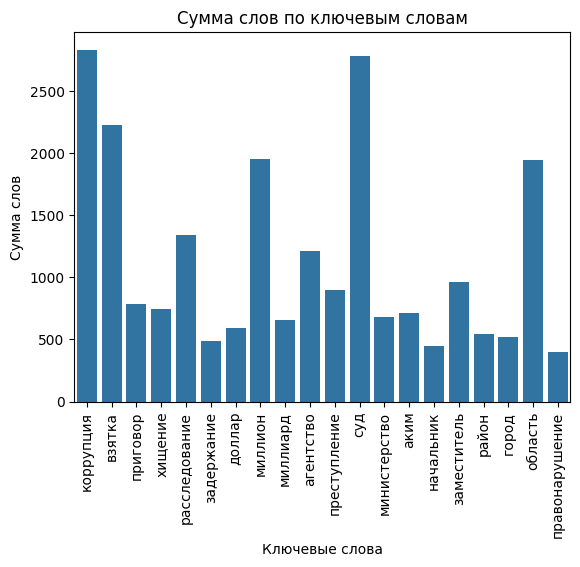

In [10]:
# Суммируем значения по каждому ключевому слову (столбцу)
keyword_sums = df.sum()

# Создаем график гистограммы (barplot)
sns.barplot(x=keyword_sums.index, y=keyword_sums.values)

# Настроим отображение графика
plt.title('Сумма слов по ключевым словам')
plt.xlabel('Ключевые слова')
plt.ylabel('Сумма слов')
plt.xticks(rotation=90)  # Поворачиваем метки по оси X для лучшего отображения
plt.show()

In [11]:
df.head()

,коррупция,взятка,приговор,хищение,расследование,задержание,доллар,миллион,миллиард,агентство,преступление,суд,министерство,аким,начальник,заместитель,район,город,область,правонарушение
Дата,,,,,,,,,,,,,,,,,,,,
2016-11-30,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,40.0,21.0,28.0,20.0,1.0,4.0,17.0,6.0,5.0,32.0,7.0
2016-12-31,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,24.0,6.0,16.0,13.0,6.0,3.0,9.0,4.0,3.0,14.0,6.0
2017-01-31,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,7.0,4.0,26.0,8.0,9.0,5.0,16.0,13.0,3.0,14.0,2.0
2017-02-28,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,5.0,10.0,43.0,8.0,3.0,5.0,3.0,3.0,9.0,14.0,3.0
2017-03-31,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,8.0,30.0,62.0,25.0,12.0,2.0,18.0,17.0,12.0,23.0,7.0


In [12]:
df.shape

(99, 20)

In [13]:
df.isna().sum()

коррупция          0
взятка             1
приговор           6
хищение            9
расследование      3
задержание        11
доллар            11
миллион            1
миллиард          12
агентство          1
преступление       2
суд                2
министерство       5
аким              10
начальник         18
заместитель        3
район             12
город              7
область            1
правонарушение     8
dtype: int64

In [14]:
df = df.fillna(1)

In [15]:
# df.to_csv("../data/processed_news_data.csv")